# HR Job Change Classification

## Project Overview

This project applies machine learning classification techniques to predict whether a candidate is likely to be looking for a job change.

The analysis covers data preprocessing, categorical feature encoding, class imbalance handling, dimensionality reduction, hyperparameter tuning, model training, and performance evaluation across multiple classification algorithms.

## Objectives

- Prepare and transform HR candidate data for machine learning
- Address class imbalance using SMOTE
- Evaluate the effect of PCA on classification performance
- Tune model hyperparameters using cross-validation
- Compare multiple classification algorithms
- Evaluate models using precision, recall, F1-score, ROC-AUC, and confusion matrices

# 1. Load Data and perform basic EDA

In [1]:
# i. Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn import preprocessing

In [2]:
# ii. Load the dataset and display number of rows and columns

df = pd.read_csv('hrdata2.csv')
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (8955, 15)


In [3]:
# iii. Display first and last 5 rows

df.head()
df.tail()

,Unnamed: 0,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
8950,19147,21319,city_21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,1.0,100-500,Pvt Ltd,1,52,1.0
8951,19149,251,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,9.0,50-99,Pvt Ltd,1,36,1.0
8952,19150,32313,city_160,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10.0,100-500,Public Sector,3,23,0.0
8953,19152,29754,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,Humanities,7.0,10/49,Funded Startup,1,25,0.0
8954,19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,50-99,Pvt Ltd,4,44,0.0


In [4]:
# iv. Show how many columns contain null values

print(df.isnull().sum())

Unnamed: 0                0
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


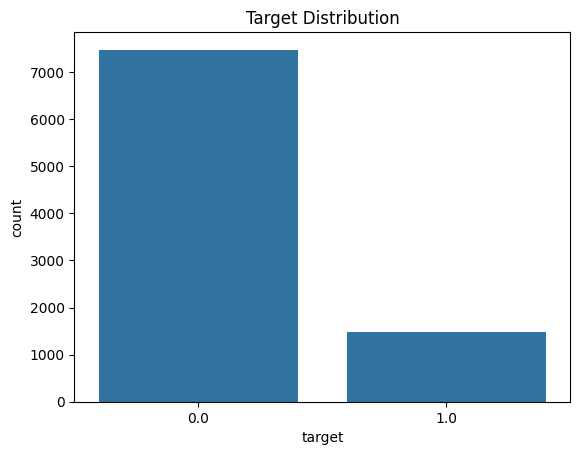

In [5]:
# v. Plot the target distribution.

sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

### Class Imbalance

The target variable is imbalanced, meaning that one class contains substantially more observations than the other.

This can cause a classification model to favor the majority class and perform poorly when identifying observations from the minority class. In this project, correctly identifying candidates who are looking for a job change is particularly important, so accuracy alone may not provide a complete picture of model performance.

Potential approaches for addressing class imbalance include:

- Resampling techniques such as SMOTE
- Class-weighted algorithms that penalize minority-class errors more heavily
- Evaluating models with precision, recall, F1-score, ROC-AUC, and precision-recall metrics rather than accuracy alone

Later in this analysis, SMOTE is applied only to the training data to create a more balanced training set.

## 2. Feature Selection and Preprocessing

### City Grouping

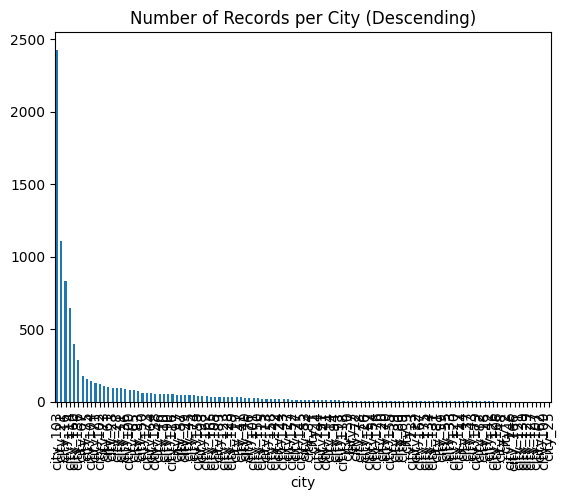

In [6]:
# Plot # of records per city (descending)
city_counts = df['city'].value_counts()

city_counts.plot(kind='bar')
plt.title('Number of Records per City (Descending)')
plt.show()


In [7]:
# II. Replace the city name with city_others if the city name is not within the top 4 city names.
top4_cities = city_counts.head(4).index

top4_count = df[df['city'].isin(top4_cities)].shape[0]
remaining_count = df[~df['city'].isin(top4_cities)].shape[0]

print("Top 4 cities total rows:", top4_count)
print("Remaining cities total rows:", remaining_count)

Top 4 cities total rows: 5021
Remaining cities total rows: 3934


In [8]:
# III. Replace the city name with city_others if the city name is not within the top 4 city names.
df['city_updated'] = df['city'].apply(lambda x: x if x in top4_cities else 'city_others')

In [9]:
# IV. Show sample rows to verify changes
df[['city', 'city_updated']].head()


,city,city_updated
0,city_40,city_others
1,city_162,city_others
2,city_46,city_others
3,city_103,city_103
4,city_103,city_103


### Education Level Encoding

In [10]:
# I. Show the unique values of education level.
print(df['education_level'].unique())

['Graduate' 'Masters' 'Phd']


In [11]:
# II. Convert the Education level column to ordinal values, like "Graduate" -> 0, Masters->1, and Phd -> 2
edu_map = {
    'Graduate': 0,
    'Masters': 1,
    'Phd': 2
}

df['education_level'] = df['education_level'].map(edu_map)

In [12]:
# III. Show some sample data that the records have changed appropriately
df[['education_level']].head()

,education_level
0,0
1,1
2,0
3,0
4,0


### Company Size Encoding

In [13]:
# I. Show the unique values of the company_size column
print(df['company_size'].unique())

['50-99' '<10' '5000-9999' '1000-4999' '10/49' '100-500' '10000+'
 '500-999']


In [14]:
# II. Change the values of the company_size column to ordinal values from 0 to 7, where '<10' is 0 and '10000+' is 7.
size_map = {
    '<10': 0,
    '10/49': 1,
    '50-99': 2,
    '100-500': 3,
    '500-999': 4,
    '1000-4999': 5,
    '5000-9999': 6,
    '10000+': 7
}

df['company_size'] = df['company_size'].map(size_map)

In [15]:
# III. Show the updated unique values
print(df['company_size'].unique())

[2 0 6 5 1 3 7 4]


### Last Job Encoding

In [16]:
# I. Show the unique values of the last_new_job column
print(df['last_new_job'].unique())

['>4' '4' '1' '3' '2' 'never']


In [17]:
# II. Convert the values of this column to never->0, 1->1,....>4 -->5
def map_last_job(x):
    if x == 'never':
        return 0
    elif x == '>4':
        return 5
    else:
        return int(x)

df['last_new_job'] = df['last_new_job'].apply(map_last_job)

In [18]:
# III. Show the updated values
print(df['last_new_job'].unique())

[5 4 1 3 2 0]


### Categorical Feature Encoding

In [19]:
# I. Show the unique values of company_type, major_descipline, enrolled_university, relevant_experience, gender, and updated city column
cols = [
    'company_type',
    'major_discipline',
    'enrolled_university',
    'relevent_experience',
    'gender',
    'city_updated'
]

for col in cols:
    print(col, df[col].unique())

company_type ['Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Public Sector' 'NGO'
 'Other']
major_discipline ['STEM' 'Humanities' 'Business Degree' 'Other' 'No Major' 'Arts']
enrolled_university ['no_enrollment' 'Part time course' 'Full time course']
relevent_experience ['No relevent experience' 'Has relevent experience']
gender ['Male' 'Female' 'Other']
city_updated ['city_others' 'city_103' 'city_114' 'city_21' 'city_16']


In [20]:
# II. Use pandas' get_dummies function to create binary columns for the values of the following columns
df = pd.get_dummies(df, columns=cols)

`pandas.get_dummies()` converts categorical variables into one-hot encoded columns directly within a DataFrame.

Scikit-learn's `OneHotEncoder` provides similar functionality and is particularly useful when categorical encoding is incorporated into a reusable machine learning pipeline.

In [21]:
# III. Show the top 5 and last 5 rows to show that the table has changed.
pd.set_option('display.max_columns', None)

df.head()
df.tail()

,Unnamed: 0,enrollee_id,city,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,gender_Female,gender_Male,gender_Other,city_updated_city_103,city_updated_city_114,city_updated_city_16,city_updated_city_21,city_updated_city_others
8950,19147,21319,city_21,0.624,0,1.0,3,1,52,1.0,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,True,False,True,False,False,False,False,True,False
8951,19149,251,city_103,0.920,1,9.0,2,1,36,1.0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,True,False,True,False,False,False,False
8952,19150,32313,city_160,0.920,0,10.0,3,3,23,0.0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False,True,False,False,False,False,False,False,True
8953,19152,29754,city_103,0.920,0,7.0,1,1,25,0.0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False,False
8954,19155,24576,city_103,0.920,0,21.0,2,4,44,0.0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,True,False,True,False,False,False,False


In [22]:
# IV. Also, show the shape of the table
print("Shape of dataset:", df.shape)

Shape of dataset: (8955, 35)


### Drop the enrollee_id and any duplicate columns

In [23]:
df.drop(columns=['enrollee_id', 'city'], inplace=True)

### Preparing Features and Target

In [24]:
# Separate predictor variables from the target variable
X = df.drop('target', axis=1)
y = df['target']

## 3. Train/Test Split, Feature Scaling, and Class Balancing

In [25]:
# Examine the class distribution before splitting
print("Class counts:")
print(y.value_counts().sort_index())

print("\nClass proportions:")
print(y.value_counts(normalize=True).sort_index())

Class counts:
target
0.0    7472
1.0    1483
Name: count, dtype: int64

Class proportions:
target
0.0    0.834394
1.0    0.165606
Name: proportion, dtype: float64


In [26]:
# Create stratified training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler using only the training data
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same transformation to the test data
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train.head()

,Unnamed: 0,city_development_index,education_level,experience,company_size,last_new_job,training_hours,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,gender_Female,gender_Male,gender_Other,city_updated_city_103,city_updated_city_114,city_updated_city_16,city_updated_city_21,city_updated_city_others
669,0.073782,0.942116,0.0,0.190476,0.285714,0.2,0.089552,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1511,0.164221,0.954092,0.0,0.047619,0.714286,0.2,0.134328,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3333,0.365777,0.654691,0.5,0.476190,0.714286,0.2,0.092537,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7004,0.783249,0.499002,0.0,0.476190,0.000000,0.2,0.038806,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4630,0.511409,0.954092,0.5,0.380952,0.285714,0.2,0.056716,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [28]:
# IV. Show the actual number and ratio of 1 and 0 in y_train and y_test

print("y_train class counts:")
print(y_train.value_counts().sort_index())

print("\ny_train class ratio:")
print(y_train.value_counts(normalize=True).sort_index())

print("\ny_test class counts:")
print(y_test.value_counts().sort_index())

print("\ny_test class ratio:")
print(y_test.value_counts(normalize=True).sort_index())

y_train class counts:
target
0.0    5230
1.0    1038
Name: count, dtype: int64

y_train class ratio:
target
0.0    0.834397
1.0    0.165603
Name: proportion, dtype: float64

y_test class counts:
target
0.0    2242
1.0     445
Name: count, dtype: int64

y_test class ratio:
target
0.0    0.834388
1.0    0.165612
Name: proportion, dtype: float64


In [29]:
# Apply SMOTE only to the training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [30]:
# Verify the training-set distribution after SMOTE

print("After SMOTE - class counts:")
print(pd.Series(y_train_res).value_counts().sort_index())

print("\nAfter SMOTE - class ratio:")
print(pd.Series(y_train_res).value_counts(normalize=True).sort_index())

After SMOTE - class counts:
target
0.0    5230
1.0    5230
Name: count, dtype: int64

After SMOTE - class ratio:
target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


## 4. PCA and Logistic Regression

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_trans

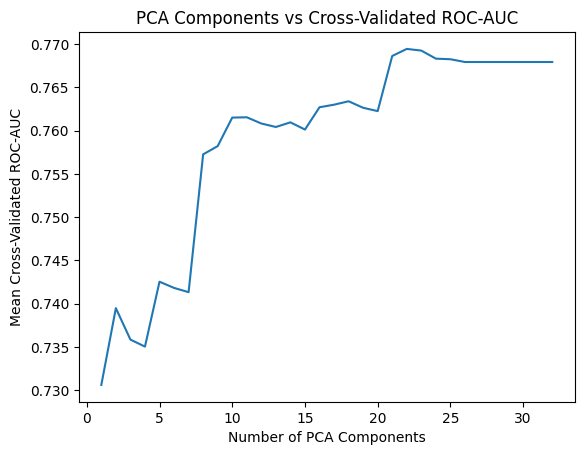

In [31]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

cv_scores = []
components = range(1, X_train.shape[1] + 1)

for n in components:
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=0)),
        ('pca', PCA(n_components=n)),
        ('logreg', LogisticRegression(max_iter=1000))
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    )

    cv_scores.append(scores.mean())

plt.plot(components, cv_scores)
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean Cross-Validated ROC-AUC')
plt.title('PCA Components vs Cross-Validated ROC-AUC')
plt.show()

In [32]:
best_n_components = list(components)[np.argmax(cv_scores)]

print("Best number of PCA components:", best_n_components)

model = Pipeline([
    ('smote', SMOTE(random_state=0)),
    ('pca', PCA(n_components=best_n_components)),
    ('logreg', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))

Best number of PCA components: 22
Accuracy: 0.799776702642352


/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_trans

In [33]:
# III.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1891  351]
 [ 187  258]]


### Logistic Regression Confusion Matrix Interpretation

The model performs well when identifying candidates in the negative class, but performance on the positive class is weaker.

The confusion matrix shows both false positives and false negatives, which is important because the positive class represents candidates looking for a job change. Therefore, accuracy alone should not be used to judge the model.

Precision, recall, F1-score, ROC-AUC, and the precision-recall curve provide additional information about how effectively the model identifies the minority class.

In [34]:
# IV.
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.84      0.88      2242
         1.0       0.42      0.58      0.49       445

    accuracy                           0.80      2687
   macro avg       0.67      0.71      0.68      2687
weighted avg       0.83      0.80      0.81      2687



/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath

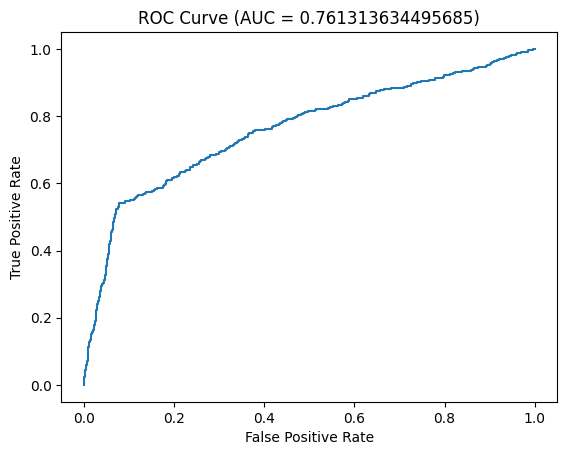

In [35]:
# V.
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc})')
plt.show()

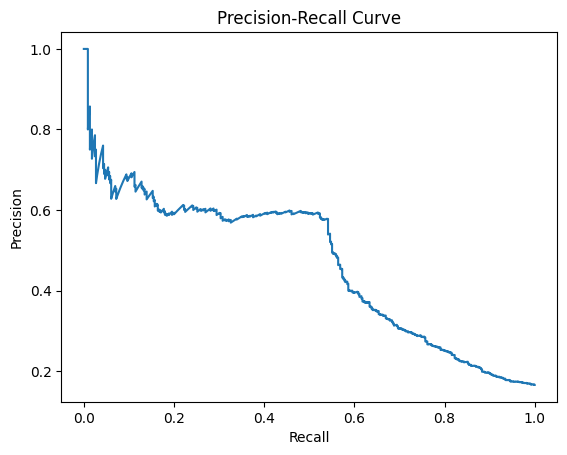

In [36]:
# VI.
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

## 5. Softmax Regression - Conceptual Background

### Relationship to Logistic Regression

Softmax regression is a generalization of logistic regression for multiclass classification. Logistic regression is commonly used for binary classification, while softmax regression assigns probabilities across multiple possible classes.

For a hypothetical model with 10 input features and 4 output classes, there would be:

- 40 feature weights: 10 features × 4 classes
- 4 bias terms: 1 bias per class

This results in a total of **44 trainable parameters**.

## 6. K-Nearest Neighbor

In [37]:
# I. Use sklearn's KNN classifier to train (with k=  10) and predict the model based on the unbalanced training set (the training set before rebalancing) and test it and show the confusion matrix and classification report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Train on original (unbalanced) training data
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Confusion Matrix
print("Confusion Matrix (Unbalanced):")
print(confusion_matrix(y_test, y_pred_knn))

# Classification Report
print("\nClassification Report (Unbalanced):")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix (Unbalanced):
[[2155   87]
 [ 312  133]]

Classification Report (Unbalanced):
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.92      2242
         1.0       0.60      0.30      0.40       445

    accuracy                           0.85      2687
   macro avg       0.74      0.63      0.66      2687
weighted avg       0.83      0.85      0.83      2687



In [38]:
# II. Use sklearn's KNN classifier to train (with k=  10) and predict the model based on the rebalanced training set and test it and show the confusion matrix and classification report

# Train on rebalanced data
knn_balanced = KNeighborsClassifier(n_neighbors=10)
knn_balanced.fit(X_train_res, y_train_res)

# Predict
y_pred_knn_balanced = knn_balanced.predict(X_test)

# Confusion Matrix
print("Confusion Matrix (Balanced):")
print(confusion_matrix(y_test, y_pred_knn_balanced))

# Classification Report
print("\nClassification Report (Balanced):")
print(classification_report(y_test, y_pred_knn_balanced))

Confusion Matrix (Balanced):
[[1701  541]
 [ 174  271]]

Classification Report (Balanced):
              precision    recall  f1-score   support

         0.0       0.91      0.76      0.83      2242
         1.0       0.33      0.61      0.43       445

    accuracy                           0.73      2687
   macro avg       0.62      0.68      0.63      2687
weighted avg       0.81      0.73      0.76      2687



In [39]:
# III. Use grid search to tune the following hyperparameters of KNN: number of neighbors (between 1 and 20), weights  (uniform or distance), and metrics (Euclidean, Manhattan, or Minkowski distance) to use for KNN.

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Create KNN model
knn = KNeighborsClassifier()

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'AUC': 'roc_auc'
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=scoring,
    refit='AUC',
    cv=5
)

# Fit using rebalanced training set
grid_search.fit(X_train_res, y_train_res)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}


In [40]:
# IV. After completing the process, print the best_params_
print("Best Parameters from Grid Search:")
print(grid_search.best_params_)

Best Parameters from Grid Search:
{'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}


In [41]:
# V. Based on the result from grid search, use the parameters to train a model, test it with test set, and then print the confusion matrix and classification report. Also, show the AUC of ROC.

from sklearn.metrics import roc_auc_score

# Train model with best parameters
best_knn = grid_search.best_estimator_

# Predict
y_pred_best = best_knn.predict(X_test)
y_prob_best = best_knn.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("Confusion Matrix (Best Model):")
print(confusion_matrix(y_test, y_pred_best))

# Classification Report
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# AUC
auc_score = roc_auc_score(y_test, y_prob_best)
print("\nAUC Score:", auc_score)

Confusion Matrix (Best Model):
[[1798  444]
 [ 193  252]]

Classification Report (Best Model):
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85      2242
         1.0       0.36      0.57      0.44       445

    accuracy                           0.76      2687
   macro avg       0.63      0.68      0.65      2687
weighted avg       0.81      0.76      0.78      2687


AUC Score: 0.7196559051408755


In [42]:
knn_pca_scores = []
knn_components = range(1, X_train.shape[1] + 1)

for n in knn_components:
    knn_pca_pipeline = Pipeline([
        ('smote', SMOTE(random_state=0)),
        ('pca', PCA(n_components=n)),
        ('knn', KNeighborsClassifier(**grid_search.best_params_))
    ])

    scores = cross_val_score(
        knn_pca_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    )

    knn_pca_scores.append(scores.mean())

best_knn_components = list(knn_components)[np.argmax(knn_pca_scores)]

print("Best PCA components for KNN:", best_knn_components)

best_knn_pca = Pipeline([
    ('smote', SMOTE(random_state=0)),
    ('pca', PCA(n_components=best_knn_components)),
    ('knn', KNeighborsClassifier(**grid_search.best_params_))
])

best_knn_pca.fit(X_train, y_train)

y_pred_pca = best_knn_pca.predict(X_test)
y_prob_pca = best_knn_pca.predict_proba(X_test)[:, 1]

print("Confusion Matrix (PCA Model):")
print(confusion_matrix(y_test, y_pred_pca))

print("\nClassification Report (PCA Model):")
print(classification_report(y_test, y_pred_pca))

auc_pca = roc_auc_score(y_test, y_prob_pca)
print("\nAUC Score (PCA Model):", auc_pca)

/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_trans

Best PCA components for KNN: 7
Confusion Matrix (PCA Model):
[[1724  518]
 [ 191  254]]

Classification Report (PCA Model):
              precision    recall  f1-score   support

         0.0       0.90      0.77      0.83      2242
         1.0       0.33      0.57      0.42       445

    accuracy                           0.74      2687
   macro avg       0.61      0.67      0.62      2687
weighted avg       0.81      0.74      0.76      2687


AUC Score (PCA Model): 0.716502119896962


/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fabrizziocapocci/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: Run

### 6-vii. Discussion of the Four KNN Models

The first KNN model was trained using the original unbalanced training data. Because the dataset contains more observations from the majority class, this model may favor the majority class and may have weaker performance when identifying candidates who are looking for a job change.

The second KNN model was trained using the SMOTE-rebalanced training data. Balancing the training set gives the classifier more opportunity to learn patterns associated with the minority class. This can improve recall for the positive class, although it can also increase the number of false positives.

The third model used GridSearchCV to find the best combination of the number of neighbors, distance metric, and weighting method. This model should generally provide better performance than using an arbitrary value of k because its hyperparameters were selected using cross-validation and AUC.

The fourth model combined PCA with the best KNN hyperparameters. PCA reduced the number of features before KNN was applied. This can reduce dimensionality and potentially remove redundant information, but reducing the number of features can also remove information that is useful for classification.

Overall, the balanced KNN models are more appropriate for this imbalanced dataset because they give the classifier a better opportunity to identify both classes. The best model should be selected based on metrics such as AUC, precision, recall, and F1-score rather than accuracy alone.

## 7. Naive Bayes

GaussianNB Confusion Matrix:
[[1053 1189]
 [ 107  338]]

GaussianNB Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.47      0.62      2242
         1.0       0.22      0.76      0.34       445

    accuracy                           0.52      2687
   macro avg       0.56      0.61      0.48      2687
weighted avg       0.79      0.52      0.57      2687



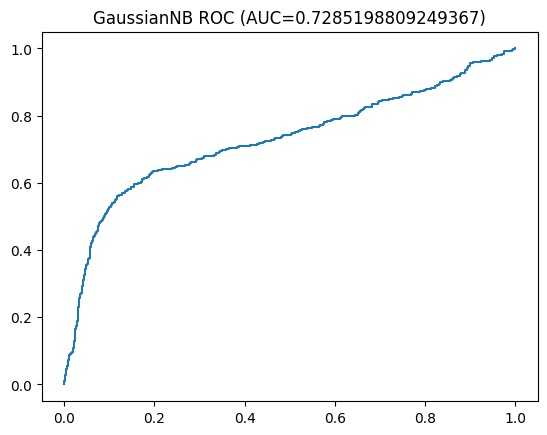

Misclassifications: 1296


In [43]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Train
gnb = GaussianNB()
gnb.fit(X_train_res, y_train_res)

# Predict
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("GaussianNB Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))

# Classification Report
print("\nGaussianNB Classification Report:")
print(classification_report(y_test, y_pred_gnb))

# ROC & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob_gnb)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"GaussianNB ROC (AUC={auc_score})")
plt.show()

# Misclassifications
print("Misclassifications:", (y_test != y_pred_gnb).sum())

## 8. Support Vector Machine

In [44]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    scoring='roc_auc'
)

grid_svm.fit(X_train_res, y_train_res)

print("Best SVM Parameters:")
print(grid_svm.best_params_)

Best SVM Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


SVM Confusion Matrix:
[[1976  266]
 [ 199  246]]

SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89      2242
         1.0       0.48      0.55      0.51       445

    accuracy                           0.83      2687
   macro avg       0.69      0.72      0.70      2687
weighted avg       0.84      0.83      0.83      2687


SVM ROC-AUC: 0.7290791728893744


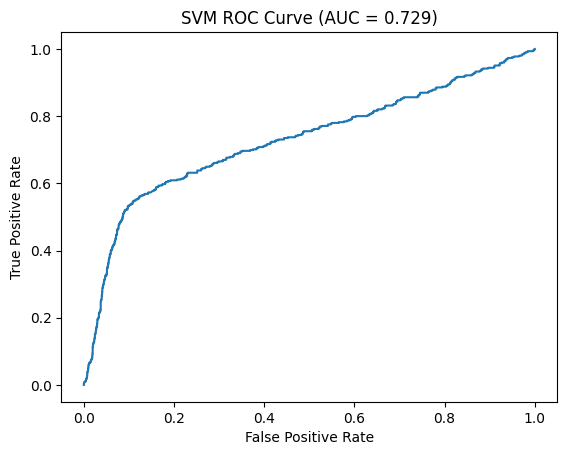

In [45]:
best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

svm_auc = roc_auc_score(y_test, y_prob_svm)

print("\nSVM ROC-AUC:", svm_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"SVM ROC Curve (AUC = {svm_auc:.3f})")
plt.show()

## 9. Decision Tree

[[2111  131]
 [ 286  159]]
              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91      2242
         1.0       0.55      0.36      0.43       445

    accuracy                           0.84      2687
   macro avg       0.71      0.65      0.67      2687
weighted avg       0.83      0.84      0.83      2687



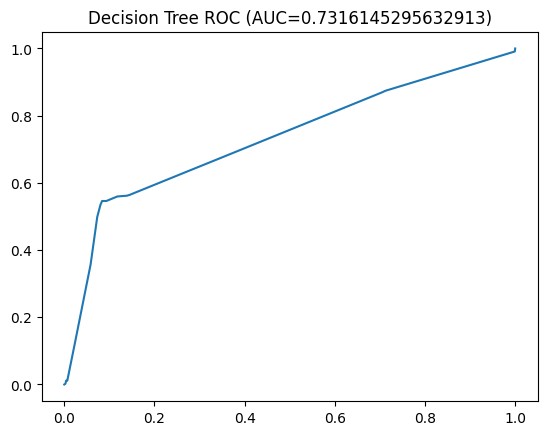

Misclassifications: 417


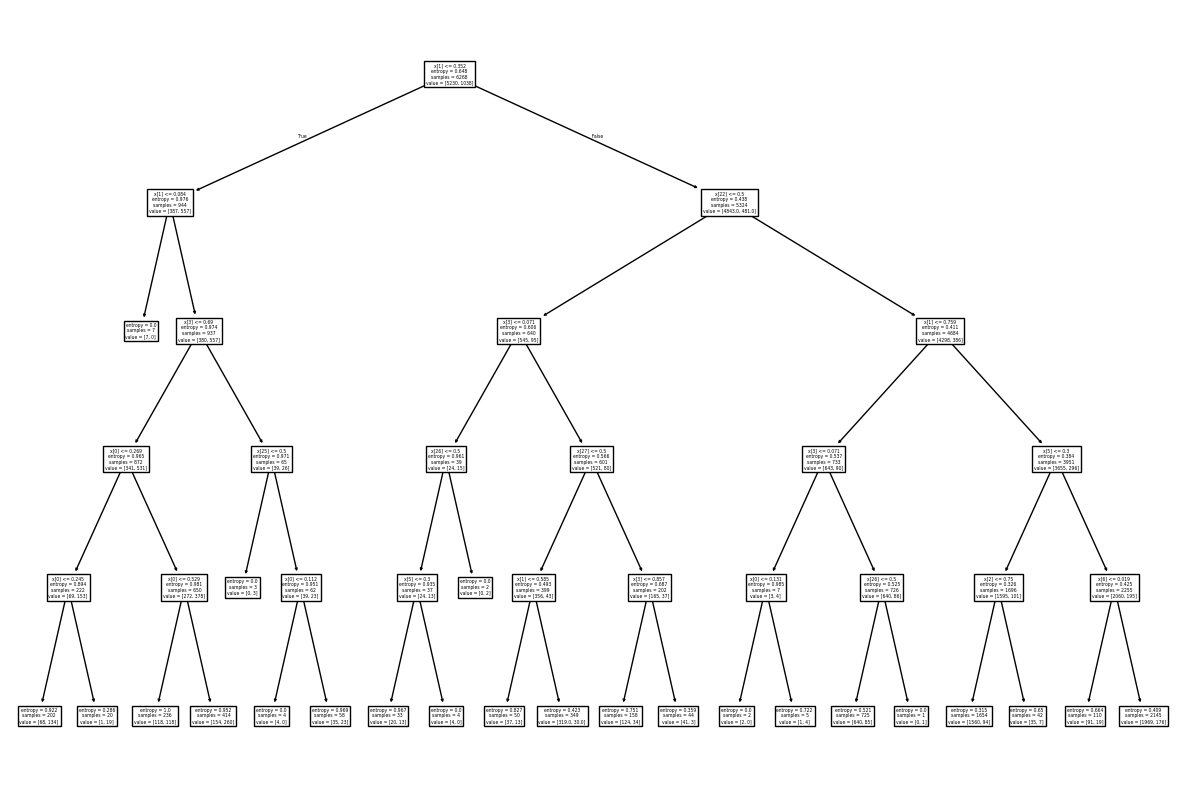

In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(criterion='entropy', max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Decision Tree ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_dt).sum())

# Plot tree
plt.figure(figsize=(15,10))
plot_tree(dt)
plt.show()

[[2037  205]
 [ 207  238]]
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      2242
         1.0       0.54      0.53      0.54       445

    accuracy                           0.85      2687
   macro avg       0.72      0.72      0.72      2687
weighted avg       0.85      0.85      0.85      2687



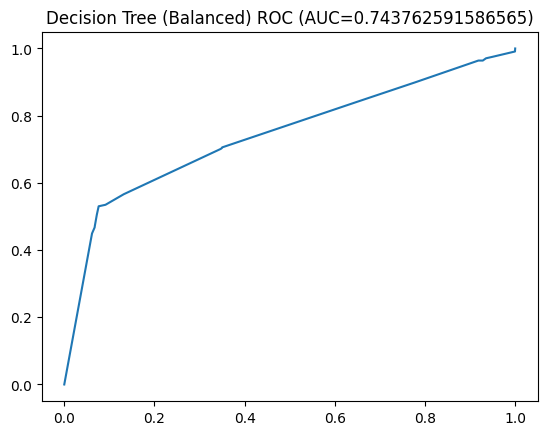

Misclassifications: 412


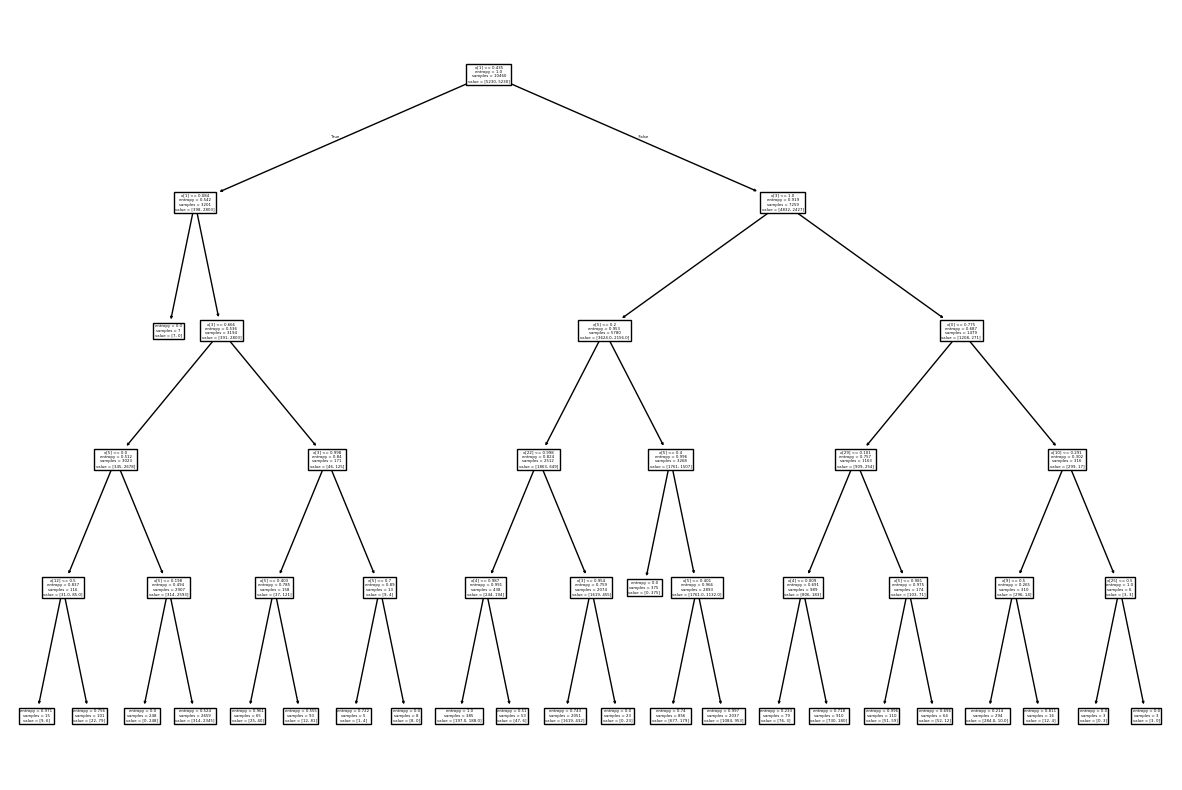

In [47]:
dt_bal = DecisionTreeClassifier(criterion='entropy', max_depth=5)
dt_bal.fit(X_train_res, y_train_res)

y_pred_dt_bal = dt_bal.predict(X_test)
y_prob_dt_bal = dt_bal.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_dt_bal))
print(classification_report(y_test, y_pred_dt_bal))

fpr, tpr, _ = roc_curve(y_test, y_prob_dt_bal)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Decision Tree (Balanced) ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_dt_bal).sum())

plt.figure(figsize=(15,10))
plot_tree(dt_bal)
plt.show()

### Decision Tree Comparison

The first decision tree was trained on the original imbalanced training set, while the second was trained on the SMOTE-balanced training set.

The unbalanced model favors the majority class more strongly. After applying SMOTE, the balanced model identifies substantially more observations from the positive class, resulting in improved recall and F1-score for that class.

However, balancing the training data does not automatically make a model better. The two models should be compared using precision, recall, F1-score, ROC-AUC, and the confusion matrix to determine which trade-off is more appropriate for the classification problem.

## 10. Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_rf.fit(X_train_res, y_train_res)

print("Best Estimator:", grid_rf.best_estimator_)

Best Estimator: RandomForestClassifier(max_depth=10, n_estimators=50)


[[2055  187]
 [ 205  240]]
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      2242
         1.0       0.56      0.54      0.55       445

    accuracy                           0.85      2687
   macro avg       0.74      0.73      0.73      2687
weighted avg       0.85      0.85      0.85      2687



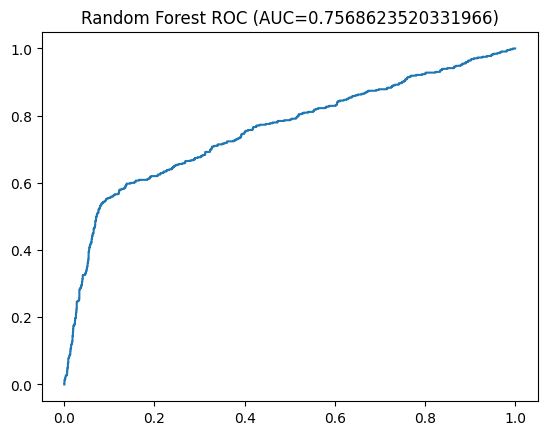

Misclassifications: 392


In [49]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Random Forest ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_rf).sum())

## 11. Boosting Algorithms

[[2051  191]
 [ 201  244]]
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      2242
         1.0       0.56      0.55      0.55       445

    accuracy                           0.85      2687
   macro avg       0.74      0.73      0.73      2687
weighted avg       0.85      0.85      0.85      2687



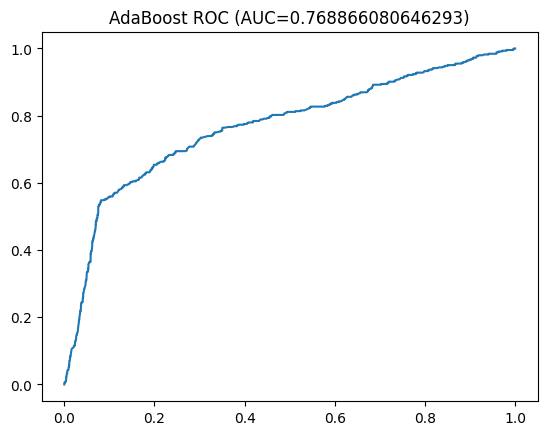

Misclassifications: 392


In [50]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_train_res, y_train_res)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

fpr, tpr, _ = roc_curve(y_test, y_prob_ada)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"AdaBoost ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_ada).sum())

[[2070  172]
 [ 213  232]]
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      2242
         1.0       0.57      0.52      0.55       445

    accuracy                           0.86      2687
   macro avg       0.74      0.72      0.73      2687
weighted avg       0.85      0.86      0.85      2687



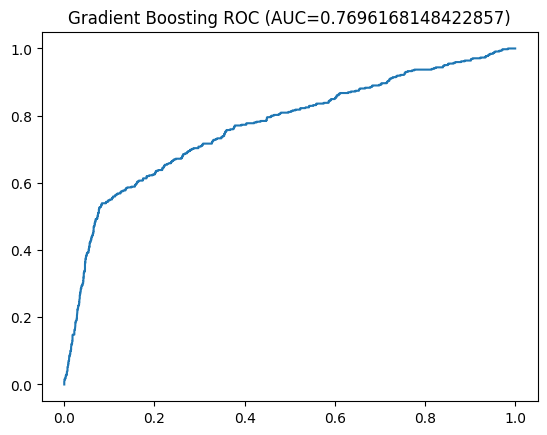

Misclassifications: 385


In [51]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Gradient Boosting ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_gb).sum())

## 12. Model Comparison and Conclusion

### Conclusion

The model comparison demonstrates why multiple evaluation metrics are important when working with an imbalanced classification problem.

Among the evaluated ensemble models, Random Forest achieved the highest overall accuracy at approximately 86% and produced strong precision for the positive class. AdaBoost achieved the highest positive-class F1-score among the final ensemble models, indicating a strong balance between precision and recall for candidates looking for a job change.

Gaussian Naive Bayes produced the highest positive-class recall, but this came at the cost of a large number of false positives and substantially lower overall accuracy. This demonstrates that optimizing a single metric can produce undesirable trade-offs.

The experiments with KNN and Decision Trees also showed the effect of class balancing. Models trained using SMOTE generally identified more positive-class observations, although this sometimes reduced overall accuracy or precision.

Overall, no single metric is sufficient for selecting the best classifier. For this problem, F1-score, recall, precision, ROC-AUC, and the confusion matrix should be considered together because identifying the minority class is an important objective.

### Future Improvements

Future work could include:

- More extensive hyperparameter optimization
- Cross-validation across all candidate models
- Threshold tuning for the positive class
- Additional feature engineering
- More advanced boosting approaches
- Comparing model performance using a standardized evaluation table